In [2]:
import gymnasium as gym
import gym_unbalanced_disk, time
import gymnasium.wrappers
import torch
import numpy as np

from torch import nn
from copy import deepcopy
from matplotlib import pyplot as plt

if not hasattr(gym_unbalanced_disk.UnbalancedDisk, '_old_reset'):
    gym_unbalanced_disk.UnbalancedDisk._old_reset = gym_unbalanced_disk.UnbalancedDisk.reset

def patched_reset(self, seed=None, options=None):
    # Call the original reset without the new keyword parameters
    return self._old_reset()

gym_unbalanced_disk.UnbalancedDisk.reset = patched_reset

raw_env = gym_unbalanced_disk.UnbalancedDisk(dt=0.025, umax=3.) 
env = gym.wrappers.TimeLimit(raw_env, max_episode_steps=200)


#env = gym_unbalanced_disk.UnbalancedDisk(dt=0.025, umax=3.) #alternative

obs, info = env.reset()
try:
    for i in range(200):
        obs, reward, terminated, truncated, info = env.step(env.action_space.sample()) #random action
        print(obs, reward)
        env.render()
        time.sleep(1/24)
        if terminated or truncated:
            obs = env.reset()
finally: #this will always run
    env.close()

[0.0109658  0.66321753] 2.6615959604056495e-11
[ 0.00368318 -1.07300021] 2.418571711081059e-11
[0.00225776 0.97702636] 2.4139155589365792e-11
[0.02022934 0.38488967] 3.148962386351251e-11
[ 0.01531468 -0.83769647] 2.852299736557371e-11
[-0.00298535 -0.46328639] 2.370337486716595e-11
[-0.03171636 -1.81899799] 3.70659289277252e-11
[-0.05094841  0.10301045] 5.130751113210961e-11
[-0.05195538 -0.08921112] 5.1735150936417237e-11
[-0.06173388 -0.58741825] 5.893846793933527e-11
[-0.09077842 -1.71089094] 9.161854164288588e-11
[-0.12581452 -1.17763149] 1.5833183607164647e-10
[-0.15692183 -1.22088528] 2.4818830889418175e-10
[-0.17893956 -0.55193381] 3.447603239154297e-10
[-0.20474478 -1.49599208] 5.034428898786662e-10
[-0.24327154 -1.63575444] 8.911265755620568e-10
[-0.25198158  0.87654348] 1.005101853003298e-09
[-0.2438795  -0.09604246] 8.870475643420887e-10
[-0.25510785 -0.89632289] 1.0622866271147332e-09
[-0.28862257 -1.47935041] 1.6272259258428657e-09
[-0.28966136  1.03187063] 1.733437119565

In [3]:
class Qfunction(nn.Module):
    def __init__(self, env):
        super(Qfunction,self).__init__()
        self.lay1 = nn.Linear(env.observation_space.shape[0], 128) #a)
        self.F1 =  nn.Tanh() #a)
        self.lay2 = nn.Linear(128, num_actions) #a)
    
    def forward(self, obs):
        return self.lay2(self.F1(self.lay1(obs))) #a)

max_episode_steps = 500
env = gym.make('unbalanced-disk-sincos-v0', dt=0.025, umax=3.) 
env = gym.wrappers.TimeLimit(env,max_episode_steps=max_episode_steps) 

#def reward_fun(self):
#    cos_th = np.cos(self.th)
#    angle_reward = 0.5 * (1.0 - cos_th)
#    top_bonus = np.exp(-(1.0 + cos_th)**2 / 0.1)
#    return angle_reward + top_bonus

#env.unwrapped.reward_fun = reward_fun

def make_env():
    env = gym.make('unbalanced-disk-sincos-v0')
    env.unwrapped.reward_fun = lambda self: 0.5 * (1.0 - np.cos(self.th))**2
    return env

env = make_env()

# Definition of discrete actions
discrete_actions = np.array([
    -3.0, -2.0, -1.0, -0.5, -0.25,
    -0.1, -0.05, -0.02,
     0.0,
     0.02, 0.05, 0.1,
     0.25, 0.5, 1.0, 2.0, 3.0
])
num_actions = len(discrete_actions)

Q = Qfunction(env)
#test validity:
obs, info = env.reset()
obs_tensor = torch.tensor(obs,dtype=torch.float32)[None,:] #convert to an torch tensor with size (1, Nobs=6)
print('obs_tensor = ', obs_tensor)
print('Q(x) = ',Q(obs_tensor)) #output #(1,Naction=3)

obs_tensor =  tensor([[ 8.9183e-04,  1.0000e+00, -4.5251e-04]])
Q(x) =  tensor([[-0.1998,  0.0659,  0.0866,  0.1300, -0.2920, -0.2688, -0.1515,  0.1851,
         -0.1143, -0.0505, -0.1844, -0.0070, -0.0121,  0.1418, -0.0452,  0.0980,
          0.4365]], grad_fn=<AddmmBackward0>)


C:\Users\Earst\anaconda3\envs\ml4sc\Lib\site-packages\gymnasium\utils\passive_env_checker.py:133: UserWarning: WARN: The obs returned by the `reset()` method was expecting numpy array dtype to be float32, actual type: float64
  logger.warn(
C:\Users\Earst\anaconda3\envs\ml4sc\Lib\site-packages\gymnasium\utils\passive_env_checker.py:157: UserWarning: WARN: The obs returned by the `reset()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")


In [3]:
#visualize
def show(Q,env):
    with torch.no_grad():
        #you can use Qfun(obs) as a shorthand for the q function.
        Qfun = lambda x: Q(torch.tensor(x[None,:],dtype=torch.float32))[0].numpy() #convert x to torch.tensor -> put in the Q function -> back to numpy
        try:
            obs, info = env.reset() #b)
            env.render() #b)
            time.sleep(1) #b)
            while True: #b)
                action = np.argmax(Qfun(obs)) #b)
                voltage_action = float(discrete_actions[action])
                obs, reward, terminated, truncated, info = env.step(voltage_action) #b)
                time.sleep(1/60) #b)
                env.render() #b)
                if terminated or truncated: #b)
                    time.sleep(0.5)  #b)
                    break  #b)
        finally: #this will always run even when an error occurs
            env.close()
 
Q = Qfunction(env)
#show(Q,env)

In [4]:
def rollout(Q, env, epsilon=0.1, N_rollout=10_000): 
    # Save the following arrays (using .append)
    Start_state = [] # hold an array of (x_t)
    Actions = []     # hold an array of (u_t)
    Rewards = []     # hold an array of (r_{t+1})
    End_state = []   # hold an array of (x_{t+1})
    Terminal = []    # hold an array of (terminal_{t+1})
    
    # Qfun(a numpy array of the obs) -> a numpy array of Q values
    Qfun = lambda x: Q(torch.tensor(x[None, :], dtype=torch.float32))[0].numpy() 
    
    with torch.no_grad():
        obs, info = env.reset()
        obs = np.array(obs, dtype=np.float32) 
        
        for i in range(N_rollout): 
            if np.random.uniform() > epsilon: 
                Qnow = Qfun(obs) 
                action = np.argmax(Qnow) 
            else: 
                action = np.random.randint(0, num_actions) 
                
            Start_state.append(obs) 
            Actions.append(action) 

            # FIX: Get the raw scalar float number out of the array mapping
            voltage_action = float(discrete_actions[action])
            
            # Pass the raw scalar value directly to the step function
            obs_next, reward, terminated, truncated, info = env.step(voltage_action) 
            obs_next = np.array(obs_next, dtype=np.float32) 

            Terminal.append(terminated) 
            Rewards.append(reward) 
            End_state.append(obs_next) 

            if terminated or truncated: 
                obs, info = env.reset() 
                obs = np.array(obs, dtype=np.float32) 
            else: 
                obs = obs_next 
                
    assert len(Start_state) == len(Actions) == len(Rewards) == len(End_state) == len(Terminal), \
        f'error in lengths: {len(Start_state)}=={len(Actions)}=={len(Rewards)}=={len(End_state)}=={len(Terminal)}'
        
    return np.array(Start_state), np.array(Actions), np.array(Rewards), np.array(End_state), np.array(Terminal).astype(int)

# Trigger and test
Q = Qfunction(env) 
Start_state, Actions, Rewards, End_state, Terminal = rollout(Q, env, N_rollout=300)
print("Data collected successfully! Shapes:")
print(f"States: {Start_state.shape}, Actions: {Actions.shape}, Rewards: {Rewards.shape}")

C:\Users\Earst\anaconda3\envs\ml4sc\Lib\site-packages\gymnasium\utils\passive_env_checker.py:133: UserWarning: WARN: The obs returned by the `step()` method was expecting numpy array dtype to be float32, actual type: float64
  logger.warn(
C:\Users\Earst\anaconda3\envs\ml4sc\Lib\site-packages\gymnasium\utils\passive_env_checker.py:157: UserWarning: WARN: The obs returned by the `step()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")


Data collected successfully! Shapes:
States: (300, 3), Actions: (300,), Rewards: (300,)


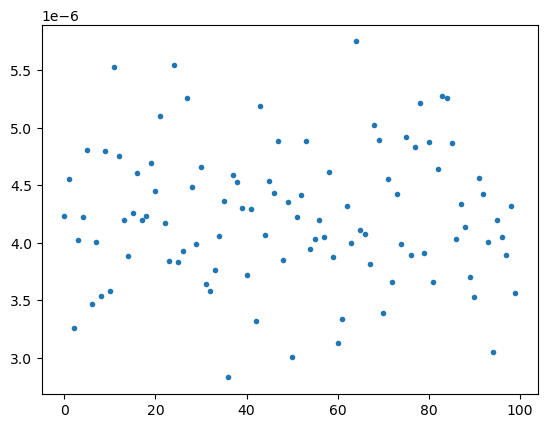

In [5]:
def eval_Q(Q,env):
    with torch.no_grad():
        Qfun = lambda x: Q(torch.tensor(x[None,:],dtype=torch.float32))[0].numpy()
        rewards_acc = 0 #d)
        obs, info = env.reset() #d)
        while True: #d)
            action = np.argmax(Qfun(obs)) #d)
            voltage_action = float(discrete_actions[action])
            obs, reward, terminated, truncated, info = env.step(voltage_action) #d)
            rewards_acc += reward #d)
            if terminated or truncated: #d)
                return rewards_acc #d)

Q = Qfunction(env) 
plt.plot([eval_Q(Q,env) for i in range(100)],'.') #d)
plt.show() #d)

In [6]:
def DQN_rollout(Q, optimizer, env, gamma=0.98, use_target_net=False, N_iterations=21, N_rollout=20000, \
                N_epochs=10, batch_size=32, N_evals=10, target_net_update_feq=100):
    best = -float('inf')
    torch.save(Q.state_dict(),'Q-checkpoint')
    try:
        for iteration in range(N_iterations):
            epsilon = max(0.05, 1.0 - iteration/(N_iterations*1.5))
            print(f'rollout iteration {iteration} with epsilon={epsilon:.2%}...')
            
            #2. rollout
            Start_state, Actions, Rewards, End_state, Terminal = rollout(Q, env, epsilon=epsilon, N_rollout=N_rollout) #e) 2.
            
            #Data conversion, no changes required
            convert = lambda x: [torch.tensor(xi,dtype=torch.float32) for xi in x]
            Start_state, Rewards, End_state, Terminal = convert([Start_state, Rewards, End_state, Terminal])
            Actions = Actions.astype(int)

            # Shuffle rollout data before batching
            perm = torch.randperm(len(Start_state))
            Start_state = Start_state[perm]
            Actions      = Actions[perm]
            Rewards      = Rewards[perm]
            End_state    = End_state[perm]
            Terminal     = Terminal[perm]

            print('starting training on rollout information...')
            t = 0
            for epoch in range(N_epochs): 
                for i in range(batch_size,len(Start_state)+1,batch_size): 
                    if t%target_net_update_feq==0:
                        Qtarget = deepcopy(Q) #g)
                        pass
                    t += 1
                    
                    Start_state_batch, Actions_batch, Rewards_batch, End_state_batch, Terminal_batch = [d[i-batch_size:i] for d in \
                                                                                                        [Start_state, Actions, Rewards, End_state, Terminal]] #e=) 3.
                    
                    with torch.no_grad(): #3.
                        if use_target_net:
                            pass
                            maxQ = torch.max(Qtarget(End_state_batch),dim=1)[0] #g)
                        else:
                            maxQ = torch.max(Q(End_state_batch),dim=1)[0] #e=) 3.
                    
                    # action_index = np.stack((np.arange(batch_size),Actions_batch),axis=0)
                    # ids = np.arange(batch_size)
                    
                    Qnow = Q(Start_state_batch)
                    # print(f'{action_index.shape=}')
                    # print(f'{Qnow.shape=}')
                    Qnow = Qnow[np.arange(batch_size), Actions_batch] #Q(x_t,u_t) is given
                    # print(Rewards_batch.shape, maxQ.shape, Terminal_batch.shape, Qnow.shape)
                    Loss = torch.mean((Rewards_batch + gamma*maxQ*(1-Terminal_batch) - Qnow)**2) #e) 3.
                    optimizer.zero_grad() #e) 3.
                    Loss.backward() #e) 3.
                    optimizer.step() #e) 3.
                
            score = np.mean([eval_Q(Q,env) for i in range(N_evals)])
            print(f'iteration={iteration} Average Reward per episode: {score:.2f}')
            if score > best:
                best = score
                print('################################# \n new best',best,'saving Q... \n#################################')
                torch.save(Q.state_dict(),'Q-checkpoint')
            
            print('loading best result')
            Q.load_state_dict(torch.load('Q-checkpoint'))
    finally: #this will always run even when using the a KeyBoard Interrupt. 
        print('loading best result')
        Q.load_state_dict(torch.load('Q-checkpoint'))

In [9]:
gamma = 0.999 #f=)
batch_size = 64 #f=)
N_iterations = 50 #f=)
N_rollout = 20000 #f=)
N_epochs = 6 #f=)
N_evals = 5 #f=)
lr = 0.005 #given
target_net_update_feq = 200

Q = Qfunction(env)
optimizer = torch.optim.Adam(Q.parameters(),lr=lr) #low learning rate
DQN_rollout(Q, optimizer, env, use_target_net=True, gamma=gamma, N_iterations=N_iterations, \
            N_rollout=N_rollout, N_epochs=N_epochs, N_evals=N_evals, batch_size=batch_size, \
            target_net_update_feq=target_net_update_feq)

rollout iteration 0 with epsilon=100.00%...
starting training on rollout information...
iteration=0 Average Reward per episode: 11.08
################################# 
 new best 11.08399209165278 saving Q... 
#################################
loading best result
rollout iteration 1 with epsilon=98.67%...
starting training on rollout information...
iteration=1 Average Reward per episode: 212.14
################################# 
 new best 212.14422961122222 saving Q... 
#################################
loading best result
rollout iteration 2 with epsilon=97.33%...
starting training on rollout information...
iteration=2 Average Reward per episode: 63.25
loading best result
rollout iteration 3 with epsilon=96.00%...
starting training on rollout information...
iteration=3 Average Reward per episode: 185.88
loading best result
rollout iteration 4 with epsilon=94.67%...
starting training on rollout information...
iteration=4 Average Reward per episode: 0.00
loading best result
rollout iter

In [ ]:
Rewards = [eval_Q(Q,env) for i in range(100)]
plt.plot(Rewards,'.')
plt.title(f'mean={np.mean(Rewards)}')
plt.xlabel('instance')
plt.ylabel('Reward per episode')
plt.show()

In [8]:
# 1. Load the optimal weights from your best training checkpoint
Q.load_state_dict(torch.load('Q-checkpoint'))

# ==========================================================
# FIX: Explicitly inject the missing render metadata attribute for Gymnasium
# ==========================================================
env.metadata = {"render_modes": ["human"]}
# ==========================================================

# 2. Re-verify the visualization routine with scalar stepping
def watch_final_policy(Q, env):
    with torch.no_grad():
        # Setup the Q-value inference lambda function
        Qfun = lambda x: Q(torch.tensor(x[None, :], dtype=torch.float32))[0].numpy() 
        
        try:
            obs, info = env.reset() 
            env.render() # Opens the simulator visual display window
            time.sleep(1) # Brief pause so you can get ready to watch
            
            rewards_accumulator = 0
            while True: 
                # Network predicts the discrete action choice index (0 to 6)
                action_idx = np.argmax(Qfun(obs)) 
                
                # Extract the pure scalar voltage matching your disk environment requirements
                voltage_action = float(discrete_actions[action_idx])
                
                # Step the environment forward using the pure scalar value
                obs_next, reward, terminated, truncated, info = env.step(voltage_action) 
                obs = np.array(obs_next, dtype=np.float32) 
                
                rewards_accumulator += reward
                
                # Match your step time delta (dt=0.025) for a smooth, true-to-life animation speed
                time.sleep(0.025) 
                env.render() 
                
                if terminated or truncated: 
                    print(f"Episode finished! Total accumulated reward: {rewards_accumulator:.2f}")
                    time.sleep(1.0) # Hold the final frame for a second
                    break  
        finally: 
            env.close() # Clean up and close the visualization window safely

# 3. Trigger the animation!
watch_final_policy(Q, env)

Episode finished! Total accumulated reward: 558.93


In [9]:
Q.load_state_dict(torch.load('Q-checkpoint'))
show(Q, env)

In [1]:
import gym_unbalanced_disk
import gymnasium as gym
import numpy as np
import torch
from matplotlib import pyplot as plt

# --------------------------------------------------
# Load trained network
# --------------------------------------------------
Q.load_state_dict(torch.load('Q-checkpoint'))
Q.eval()

umax = 3.0
dt = 0.025

# --------------------------------------------------
# Verify policy in simulation first
# --------------------------------------------------
print("=== SIMULATION TEST ===")

env_sim = gym.make(
    'unbalanced-disk-sincos-v0',
    dt=dt,
    umax=umax
)

obs, info = env_sim.reset()
obs = np.array(obs, dtype=np.float32)

reward_sum = 0
top_counter = 0

with torch.no_grad():
    Qfun = lambda x: Q(
        torch.tensor(x[None, :], dtype=torch.float32)
    )[0].numpy()

    for k in range(500):
        # Simulation observation is already [sin(theta), cos(theta), omega]
        action_idx = np.argmax(Qfun(obs))
        voltage = float(discrete_actions[action_idx])

        # Step the SIMULATION environment
        obs, reward, terminated, truncated, info = env_sim.step(voltage)
        obs = np.array(obs, dtype=np.float32)

        reward_sum += reward

        # If cos(theta) < -0.95, it's near the upright top position
        if obs[1] < -0.95:
            top_counter += 1

        if terminated or truncated:
            break

print(f"Simulation reward: {reward_sum:.2f}")
print(f"Final cos(theta): {obs[1]:.3f}")
print(f"Time near top: {100*top_counter/max(k,1):.1f}%")

env_sim.close()


# --------------------------------------------------
# Real hardware deployment
# --------------------------------------------------
print("\n=== REAL HARDWARE ===")

env_exp = gym_unbalanced_disk.UnbalancedDisk_exp(
    umax=umax,
    dt=dt
)

obs, info = env_exp.reset()

obs_list = []
action_list = []
reward_list = []

try:
    with torch.no_grad():
        Qfun = lambda x: Q(
            torch.tensor(x[None, :], dtype=torch.float32)
        )[0].numpy()

        for k in range(500):
            # 1. Extract raw continuous values from the encoder
            theta_raw = float(obs[0])
            omega_raw = float(obs[1])

            # 2. Wrap continuous raw encoder to [-pi, pi] to keep frame bounded
            theta_wrapped = np.arctan2(np.sin(theta_raw), np.cos(theta_raw))
            
            theta_sim = theta_wrapped 
            omega_sim = omega_raw

            # 3. Construct the exact 3-feature vector the network expects
            obs_sincos = np.array([
                np.sin(theta_sim),
                np.cos(theta_sim),
                omega_sim
            ], dtype=np.float32)

            # 4. Q-network action selection
            action_idx = np.argmax(Qfun(obs_sincos))
            voltage = float(discrete_actions[action_idx])

            # 5. Fix motor polarity discrepancy (flip sign)
            voltage_corrected = -voltage 
            voltage_corrected = np.clip(voltage_corrected, -umax, umax)

            if k % 40 == 0:
                print(
                    f"step={k:3d} | "
                    f"theta_wrapped={np.degrees(theta_sim):6.1f}° | "
                    f"omega={omega_sim:6.2f} | "
                    f"u_sent={voltage_corrected:5.2f}V"
                )

            # Step the PHYSICAL hardware
            obs_next, reward, terminated, truncated, info = env_exp.step(voltage_corrected)

            # Save the processed sincos observation tracking for plotting
            obs_list.append(obs_sincos.copy())
            action_list.append(voltage_corrected)
            reward_list.append(reward)

            obs = obs_next

            if terminated or truncated:
                break

finally:
    print("\nStopping hardware safely...")
    try:
        env_exp.reset()
    except:
        pass
    env_exp.close()


# --------------------------------------------------
# Plotting Results
# --------------------------------------------------
obs_arr = np.array(obs_list)

if len(obs_arr) > 0:
    t = np.arange(len(obs_arr)) * dt

    # Reconstruct angle in degrees from your saved sin/cos states
    theta_deg = np.degrees(np.arctan2(obs_arr[:, 0], obs_arr[:, 1]))

    plt.figure(figsize=(10, 8))

    plt.subplot(3, 1, 1)
    plt.plot(t, theta_deg, label='Hardware angle', color='blue')
    plt.axhline(180, color='r', linestyle='--', label='Upright Goal')
    plt.axhline(-180, color='r', linestyle='--')
    plt.ylabel('Theta [deg]')
    plt.grid(True)
    plt.legend()

    plt.subplot(3, 1, 2)
    plt.plot(t, obs_arr[:, 2], color='orange')
    plt.ylabel('Omega [rad/s]')
    plt.grid(True)

    plt.subplot(3, 1, 3)
    plt.plot(t, action_list, color='green')
    plt.ylabel('Voltage Applied [V]')
    plt.xlabel('Time [s]')
    plt.grid(True)

    plt.tight_layout()
    plt.show()

NameError: name 'Q' is not defined

In [ ]:
env.close()